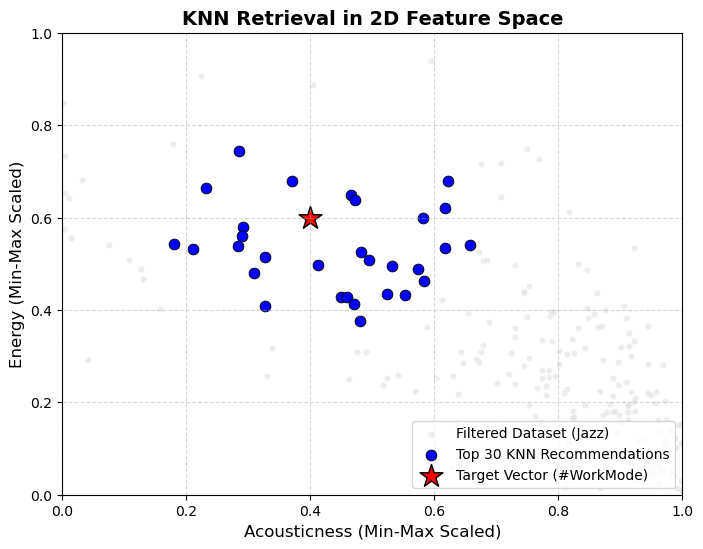

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load preprocessed dataset
df_jazz = pd.read_csv("processed_spotify_data.csv") 
df_jazz = df_jazz[df_jazz['track_genre'] == 'jazz']

# 2. Define Target Vector
target_acousticness = 0.4
target_energy = 0.6

# 3. Simulate KNN retrieval
df_jazz['distance'] = ((df_jazz['acousticness'] - target_acousticness)**2 + 
                       (df_jazz['energy'] - target_energy)**2)**0.5
retrieved_tracks = df_jazz.nsmallest(30, 'distance')

# 4. Create the Academic Scatter Plot
plt.figure(figsize=(8, 6))

# Plot the background dataset
sns.scatterplot(data=df_jazz, x='acousticness', y='energy', 
                color='lightgrey', alpha=0.4, s=20, label='Filtered Dataset (Jazz)')

# Plot the 30 KNN Retrieved Tracks
sns.scatterplot(data=retrieved_tracks, x='acousticness', y='energy', 
                color='blue', edgecolor='black', s=60, label='Top 30 KNN Recommendations')

# Plot the Target Vector (The Star)
plt.scatter(x=target_acousticness, y=target_energy, 
            color='red', marker='*', s=300, edgecolor='black', 
            label='Target Vector (#WorkMode)')

# Formatting
plt.xlabel('Acousticness (Min-Max Scaled)', fontsize=12)
plt.ylabel('Energy (Min-Max Scaled)', fontsize=12)
plt.title('KNN Retrieval in 2D Feature Space', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

# Save image
plt.savefig('knn_scatter.png', dpi=300, bbox_inches='tight')
plt.show()